In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
import tensorflow as tf
from tensorflow.keras.models import Sequential 
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model
from tensorflow import keras
from copy import copy, deepcopy
from tensorflow.keras.layers import *
from tensorflow.keras.utils import to_categorical

In [3]:
!pip install scikit-learn

In [ ]:
# Replace __FILL_ME__ with your information

# Data preparation and prepcrossing

In [4]:
# load data
(data_train, label_train), (data_test, label_test) = mnist.load_data()

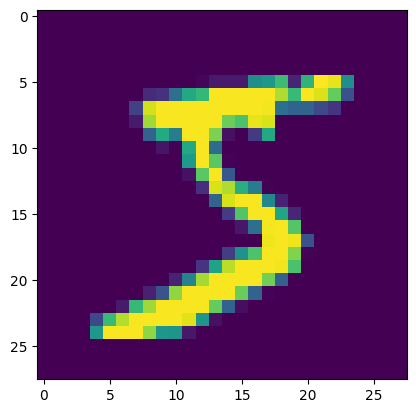

In [5]:
# display one test figure
test_fig = data_train[0]
plt.imshow(test_fig)

In [6]:
# normalize the data into the range of 0-1
data_train = data_train/data_train.max()
data_test = data_test/data_test.max()

Label = 0


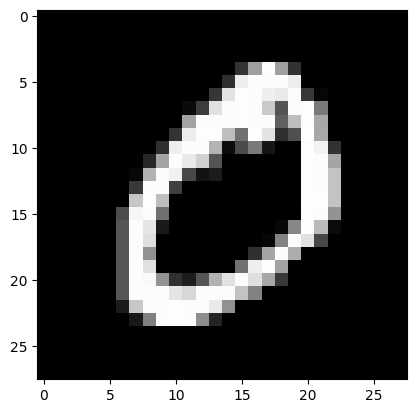

Label = 1


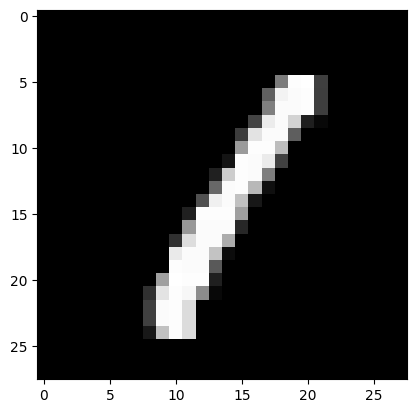

Label = 2


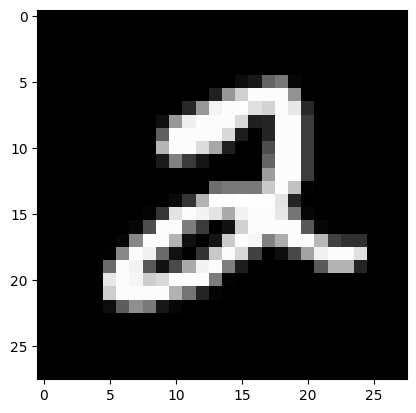

Label = 3


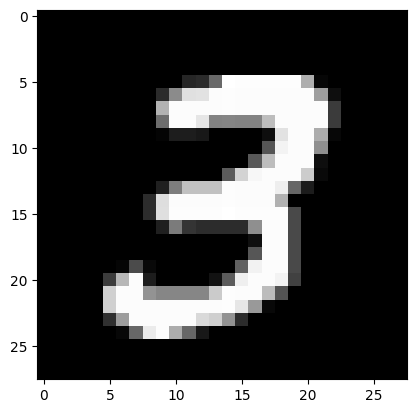

Label = 4


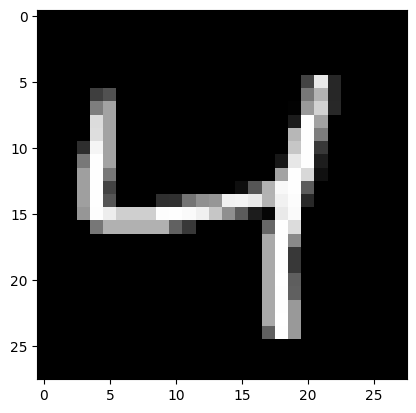

Label = 5


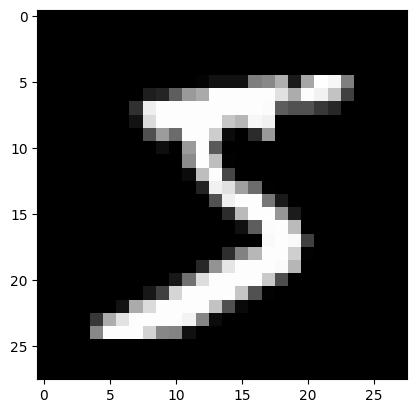

Label = 6


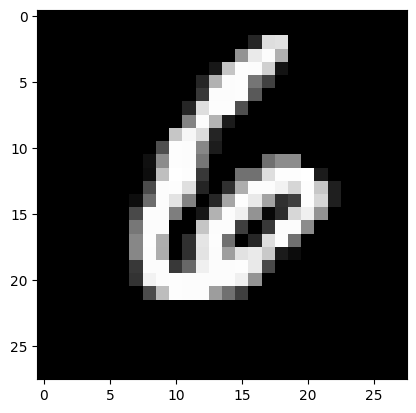

Label = 7


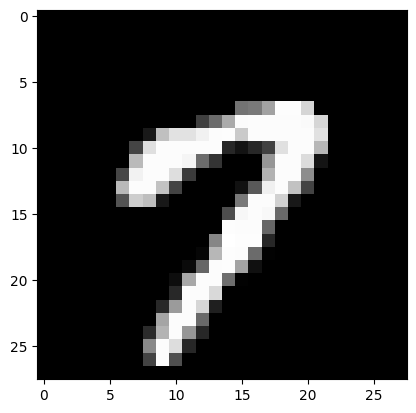

Label = 8


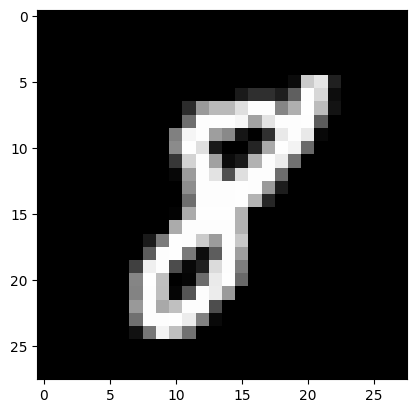

Label = 9


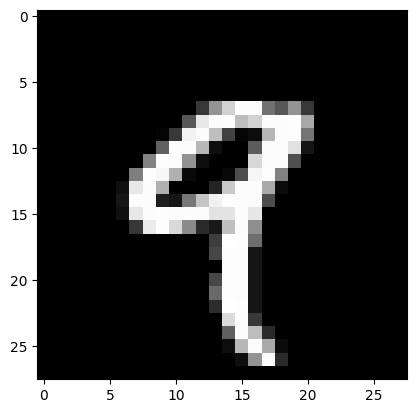

In [7]:
# display fig for each class
for i in range(10):
    for img_idx in range(10000):
        if int(label_train[img_idx]) == i:
            print('Label =', i)
            plt.imshow(data_train[img_idx],cmap = 'gray')
            plt.show()
            break
    

In [8]:
# 32 Floating Point data type is used
mem_fig = (28 * 28 * 4) / 1024
print('The required memory useage for each figure is:{} kb' .format(mem_fig) )

The required memory useage for each figure is:3.0625 kb


# Construct the MLP

In [ ]:
# Considerations: number of layers, number of neurons in each layer, activation function

In [9]:
# Build up the MLP
# later you can change the number of neurons and layers

input_layer = Input(shape= data_train[0].shape)
input_layer_f = Flatten()(input_layer)

hidden_layer_1     = Dense(5, name='dense_1')(input_layer_f)
hidden_layer_1_act = Activation("relu", name="act_1")(hidden_layer_1)

hidden_layer_2     = Dense(8, name='dense_2')(hidden_layer_1_act)
hidden_layer_2_act = Activation("relu", name="act_2")(hidden_layer_2)

hidden_layer_3     = Dense(8, name='dense_3')(hidden_layer_2_act)
hidden_layer_3_act = Activation("relu", name="act_3")(hidden_layer_3)

output_layer       = Dense(10, name='output_layer')(hidden_layer_3_act)
output_layer_act   = Activation("softmax", name="softmax")(output_layer)

model = Model(input_layer, output_layer_act)


In [10]:
parameter_by_layer = np.zeros([4])

# layer 1
parameter_by_layer[0] = (784 * 128) + 128
# layer 2
parameter_by_layer[1] = (128 * 64) + 64
# layer 3 
parameter_by_layer[2] = (64 * 32) + 32
# layer 4
parameter_by_layer[3] = (32 * 10) + 10

# Nhân với 4 bytes và chia cho 1024 để đổi ra KB (hoặc chia 1000 tùy theo barem của slide)
mem_model = parameter_by_layer.sum() * 4 / 1024

print('The total memory usage for weights and bias is {} kb' .format(mem_model))

The total memory usage for weights and bias is 434.1640625 kb


In [11]:
# check the parameter numbers
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 28, 28)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │           3,925 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ act_1 (Activation)                   │ (None, 5)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │              48 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ act_2 (Activation)                   │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ act_3 (Activation)                   │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 10)                  │              90 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ softmax (Activation)                 │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,135 (16.15 KB)

 Trainable params: 4,135 (16.15 KB)

 Non-trainable params: 0 (0.00 B)

# Model Training

In [12]:
# compile model
# define optimizer to perform backpropagation, loss function to evaluate loss
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [13]:
# train model with 80% data for training and 20% for validation with specified number of epochs, a small number is recommended (10)
r= model.fit(data_train, label_train,  validation_split= 0.2, epochs=10)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.6207 - loss: 1.1125 - val_accuracy: 0.8080 - val_loss: 0.6594
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8242 - loss: 0.6101 - val_accuracy: 0.8551 - val_loss: 0.5103
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8579 - loss: 0.5029 - val_accuracy: 0.8743 - val_loss: 0.4477
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8750 - loss: 0.4451 - val_accuracy: 0.8885 - val_loss: 0.3985
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8825 - loss: 0.4112 - val_accuracy: 0.8938 - val_loss: 0.3745
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8890 - loss: 0.3912 - val_accuracy: 0.8964 - val_loss: 0.3622
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8933 - loss: 0.3759 - val_accuracy: 0.8978 - val_loss: 0.3572
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8965 - loss: 0.3655 

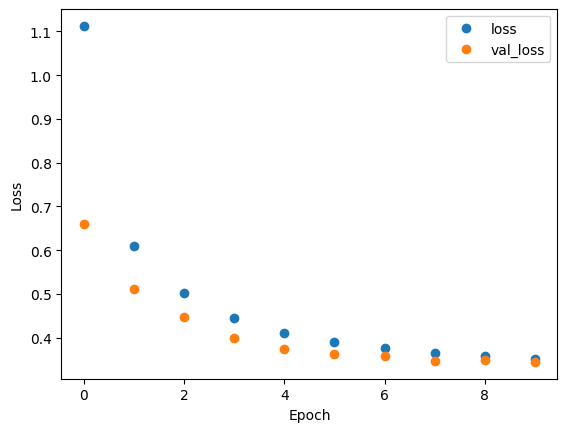

In [15]:
# plot loss
plt.plot(r.history['loss'],  'o', label='loss')
plt.plot(r.history['val_loss'],'o', label='val_loss',)
plt.ylabel('Loss')  # Set the label for the y-axis
plt.xlabel('Epoch')  # Set the label for the x-axis
plt.legend()
plt.show()

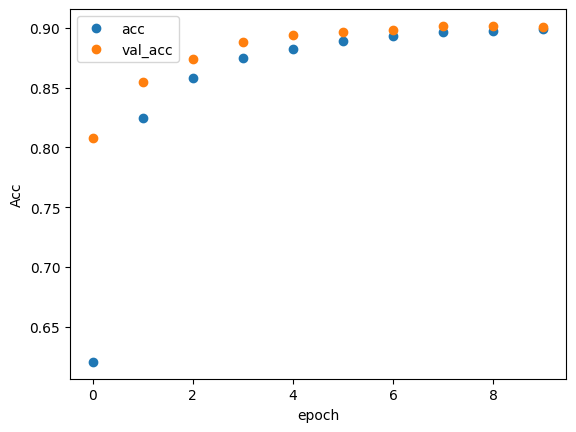

In [16]:
# Plot accuracy
plt.plot(r.history['accuracy'], 'o', label='acc')
plt.plot(r.history['val_accuracy'], 'o', label='val_acc')
plt.xlabel('epoch')
plt.ylabel('Acc')
plt.legend()
plt.show()

In [17]:
# Evaluate the model with test dataset - evaluate() returns loss and accuracy
print("Train Acc", model.evaluate(data_train, label_train)[1])
acc_floatingpoint =  model.evaluate(data_test, label_test)[1]
print("Test Acc:",acc_floatingpoint )

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9023 - loss: 0.3409
Train Acc 0.9023000001907349
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9009 - loss: 0.3460
Test Acc: 0.9009000062942505


In [18]:
# save model weights
model.save_weights("weights_floatingpoint.weights.h5")

Text(0, 0.5, 'Number')

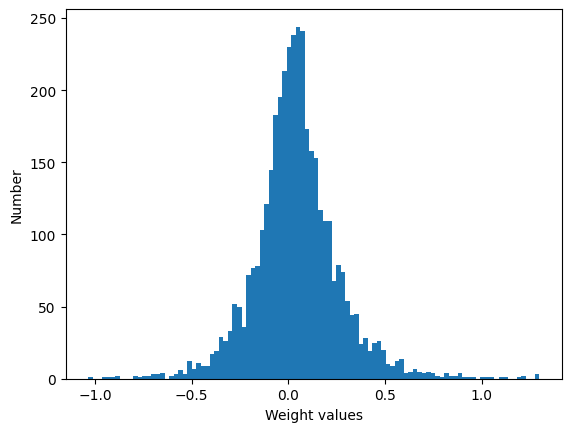

In [19]:
# observe the statistics of weights, for example in the first layer
_ = plt.hist((model.get_weights()[0].flatten()), bins = 100)
plt.xlabel('Weight values')
plt.ylabel('Number')

In [ ]:
# # What can you observe from the distribution of weights?
# Normal (Gaussian) Distribution: The weights form a clean bell-shaped curve centered tightly around 0. This indicates that the training was stable and the model learned balanced positive/negative features.

# Narrow Range: Almost all weights fall within a very small interval (typically between -0.5 and 0.5 or -1 and 1).

# Implement of the trained MLP with numpy

In [20]:
# implement the dense layer
def dense_layer(input_mat, input_vec, bias):
    output = np.dot(input_vec, input_mat) + bias
    return output

In [21]:
# implement the ReLU activation function
def ReLU_layer(in_activations):
    out_activations = np.zeros(in_activations.shape)
    for i in range(len(in_activations)):
        if in_activations[i] > 0:
            out_activations[i] = in_activations[i]
    return out_activations

In [22]:
# implement the softmax activation function
def softmax_layer (in_activations):
    out_activations = np.zeros(in_activations.shape)
    
    # Subtracting the max value prevents numerical overflow (NaN errors)
    shift_activations = in_activations - np.max(in_activations)
    exp_sum = np.sum(np.exp(shift_activations))
    
    for i in range(len(in_activations)):
        out_activations[i] = np.exp(shift_activations[i]) / exp_sum
    return out_activations

In [23]:
# Extract weights and biases only from layers that have them (the Dense layers)
dense_layers = [layer for layer in model.layers if len(layer.get_weights()) > 0]

W1, b1 = dense_layers[0].get_weights()
W2, b2 = dense_layers[1].get_weights()
W3, b3 = dense_layers[2].get_weights()
W4, b4 = dense_layers[3].get_weights()

input_example_np = np.ones([28*28])

# Layer 1: Input (784) -> Dense 1 (128) -> ReLU
output_1 = ReLU_layer(dense_layer(W1, input_example_np, b1))

# Layer 2: Dense 1 (128) -> Dense 2 (64) -> ReLU
output_2 = ReLU_layer(dense_layer(W2, output_1, b2))

# Layer 3: Dense 2 (64) -> Dense 3 (32) -> ReLU
output_3 = ReLU_layer(dense_layer(W3, output_2, b3))

# Layer 4: Dense 3 (32) -> Dense 4 / Output (10) -> Softmax
output_4 = softmax_layer(dense_layer(W4, output_3, b4))

In [24]:
# Compare with the reference
model.predict(tf.ones((1, 28, 28)), steps=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step


array([[0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 3.5798151e-29,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 7.6074615e-37,
        4.5203777e-36, 0.0000000e+00]], dtype=float32)

# MLP fixed point quantization

In [ ]:
# Quantized the weights and evaluate the best combination of Integer and Fractional parts
# Compare the inference acc. with TF model
# Estimate how much memory storage you can save with quantization 

In [25]:
def fixP_quantization(input_weight, int_BW, frac_BW):
    # LSB step size: smallest value representable by the fractional bits
    resolution_ = 2 ** (-frac_BW)
    
    # Negative boundary limit (magnitude) determined by the integer bits
    range_ = 2 ** int_BW 
    
    # Create a deep copy to avoid modifying the original weight array in-place
    weight = deepcopy(input_weight)
    
    # Clip weights to the safe signed fixed-point range: [-range, range - resolution]
    input_weight_clipped = np.clip(weight, -range_, range_ - resolution_) 
    
    # Scale to integer grid, round to the nearest whole number, and scale back
    input_weight_quantized = np.round(input_weight_clipped / resolution_) * resolution_
    
    return input_weight_quantized

In [26]:
# weight_quantization
BW_int = 2      
BW_frac = 5

In [27]:
weight_quantized = [deepcopy(w) for w in model.get_weights()]

In [28]:
for i in range(len(weight_quantized)):
    weight_quantized[i] = fixP_quantization(np.copy(weight_quantized[i]), BW_int, BW_frac)

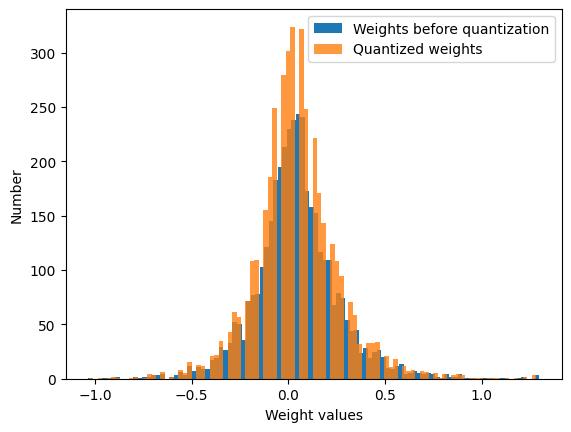

In [29]:
# plot the quantized weights in the first layer as example and compare with the floating point
_ = plt.hist((model.get_weights()[0].flatten()), bins = 100, label = 'Weights before quantization', alpha = 1)
_ = plt.hist((weight_quantized[0].flatten()), bins = 100, label = 'Quantized weights', alpha = 0.8)
plt.xlabel('Weight values')
plt.ylabel('Number')

plt.legend()

In [30]:
# define the quantized model
model_quantized = Model(input_layer, output_layer_act)

In [31]:
# load weights and save 
model_quantized.set_weights(weight_quantized)
model_quantized.save_weights("weights_q_int{}_frac_{}.weights.h5".format(BW_int, BW_frac))

# Evaluation of the quantization 

In [32]:
model_quantized.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [33]:
# Evaluate the model - evaluate() returns loss and accuracy
print("Train Acc", model_quantized.evaluate(data_train, label_train)[1])
acc_quantized = model_quantized.evaluate(data_test, label_test)[1]
print("Test Acc:", acc_quantized)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9005 - loss: 0.3479
Train Acc 0.9004999995231628
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8991 - loss: 0.3530
Test Acc: 0.8991000056266785


In [35]:
# Summary
# 32 FP numbers utilized in baseline model
mem_model_quantized = parameter_by_layer.sum() * 1 / 1024
saved_memory = mem_model - mem_model_quantized

acc_drop = acc_floatingpoint - acc_quantized

In [36]:
print("Saved memory: {}% ".format(saved_memory*100))
print("Accuracy drop: {:.2f}%" .format(acc_drop*100))

Saved memory: 32562.3046875% 
Accuracy drop: 0.18%


In [37]:
# Lấy danh sách tất cả các tham số của mô hình gốc
weights_and_biases = model.get_weights()

# Trong mô hình MLP của bạn:
# - Chỉ số chẵn (0, 2, 4, 6) chứa Ma trận Trọng số (Weights)
# - Chỉ số lẻ (1, 3, 5, 7) chứa Vector Độ lệch (Biases)

# Lớp thứ nhất (Dense 1):
W1 = weights_and_biases[0]
b1 = weights_and_biases[1]

# Lớp thứ hai (Dense 2):
W2 = weights_and_biases[2]
b2 = weights_and_biases[3]

# Lớp thứ ba (Dense 3):
W3 = weights_and_biases[4]
b3 = weights_and_biases[5]

# Lớp thứ tư / Đầu ra (Dense 4):
W4 = weights_and_biases[6]
b4 = weights_and_biases[7]

# In thử kích thước (shape) để kiểm tra
print("Dense 1 - W1 shape:", W1.shape, "| b1 shape:", b1.shape)
print("Ví dụ một vài giá trị W1:\n", W1[:2, :2])

Dense 1 - W1 shape: (784, 5) | b1 shape: (5,)
Ví dụ một vài giá trị W1:
 [[-0.      -0.0625 ]
 [-0.0625   0.03125]]


In [39]:
import os

# Đường dẫn thẳng tới thư mục Lab7 của bạn
path_lab7 = r"D:\SumSem_Pots\Hardware\Lab\Lab7\mlp_FP"

# Tạo đường dẫn đầy đủ cho 2 file
neuron_file_path = os.path.join(path_lab7, "neuron.h")
input_file_path = os.path.join(path_lab7, "mnist_input_sample.h")

# ==========================================
# 1. TẠO VÀ GHI THẲNG FILE NEURON.H VÀO LAB7
# ==========================================
with open(neuron_file_path, "w") as f:
    f.write("#ifndef NEURON_H\n#define NEURON_H\n\n")
    
    # Ghi Weight và Bias lớp 1
    f.write("float W1[784][5] = {\n")
    for row in W1:
        f.write("    {" + ", ".join(map(str, row)) + "},\n")
    f.write("};\n\n")
    f.write("float b1[5] = {" + ", ".join(map(str, b1)) + "};\n\n")
    
    # Ghi Weight và Bias lớp 2
    f.write("float W2[5][8] = {\n")
    for row in W2:
        f.write("    {" + ", ".join(map(str, row)) + "},\n")
    f.write("};\n\n")
    f.write("float b2[8] = {" + ", ".join(map(str, b2)) + "};\n\n")
    
    # Ghi Weight và Bias lớp 3
    f.write("float W3[8][8] = {\n")
    for row in W3:
        f.write("    {" + ", ".join(map(str, row)) + "},\n")
    f.write("};\n\n")
    f.write("float b3[8] = {" + ", ".join(map(str, b3)) + "};\n\n")
    
    # Ghi Weight và Bias lớp 4
    f.write("float W4[8][10] = {\n")
    for row in W4:
        f.write("    {" + ", ".join(map(str, row)) + "},\n")
    f.write("};\n\n")
    f.write("float b4[10] = {" + ", ".join(map(str, b4)) + "};\n\n")
    
    f.write("#endif\n")

print(f"-> Đã ghi neuron.h trực tiếp vào: {neuron_file_path}")


# ==========================================
# 2. TẠO VÀ GHI THẲNG FILE MNIST_INPUT_SAMPLE.H VÀO LAB7
# ==========================================
single_input_flat = data_test[0].flatten()

with open(input_file_path, "w") as f:
    f.write(",\n".join(map(str, single_input_flat)))

print(f"-> Đã ghi mnist_input_sample.h trực tiếp vào: {input_file_path}")
print(f"-> Nhãn thực tế (Golden Label) của ảnh này là: {label_test[0]}")

-> Đã ghi neuron.h trực tiếp vào: D:\SumSem_Pots\Hardware\Lab\Lab7\mlp_FP\neuron.h
-> Đã ghi mnist_input_sample.h trực tiếp vào: D:\SumSem_Pots\Hardware\Lab\Lab7\mlp_FP\mnist_input_sample.h
-> Nhãn thực tế (Golden Label) của ảnh này là: 7
